In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

print("pandas", pd.__version__)


key = pd.read_csv(r"C:\Users\Alex\OneDrive\Desktop\ML-1\key.csv")
message = pd.read_csv(r"C:\Users\Alex\OneDrive\Desktop\ML-1\message.csv")
codebook = pd.read_csv(r"C:\Users\Alex\OneDrive\Desktop\ML-1\codebook.csv")

pandas 3.0.5


,pos,shift,relay
0,0,NaN,LaTrappe-42
1,1,121,LaTrappe-42
2,2,83,LaTrappe-42
3,3,174,LaTrappe-42
4,4,NaN,LaTrappe-42


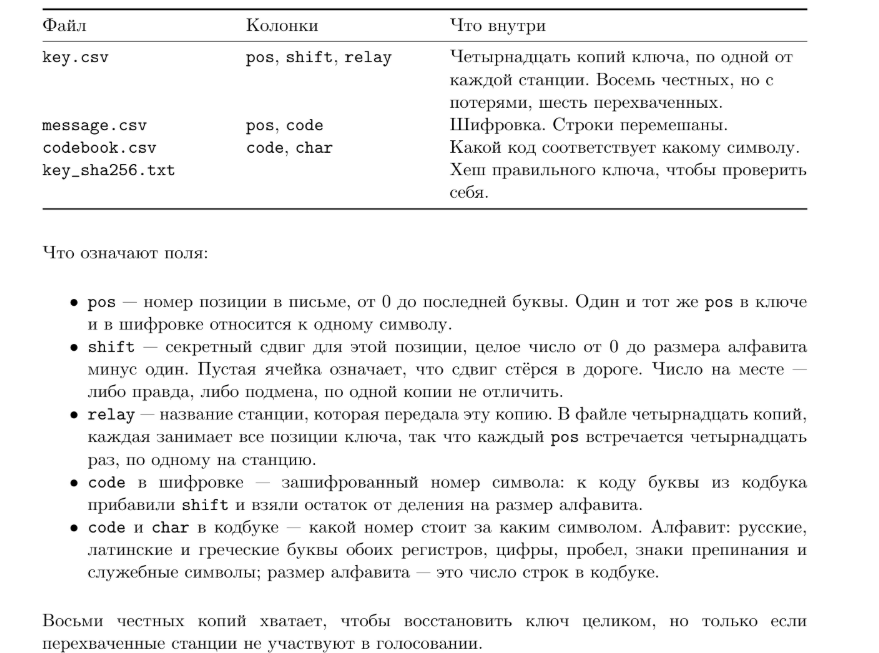

In [16]:
print(key.shape)
print(message.shape)
print(codebook.shape)

(2128, 3)
(152, 2)
(211, 2)


In [8]:
message.head()

,pos,code
0,73,170
1,12,3
2,90,137
3,22,45
4,62,155


In [15]:
codebook.head()

,code,char
0,97,а
1,11,б
2,27,в
3,48,г
4,45,д


In [51]:
key.head()

,pos,shift,relay
0,0,NaN,LaTrappe-42
1,1,121,LaTrappe-42
2,2,83,LaTrappe-42
3,3,174,LaTrappe-42
4,4,NaN,LaTrappe-42


In [14]:
print(key.dtypes)
print(message.dtypes)
print(codebook.dtypes)

pos      int64
shift      str
relay      str
dtype: object
pos     int64
code    int64
dtype: object
code    int64
char      str
dtype: object


In [23]:
key.isna().sum()

pos        0
shift    340
relay      0
dtype: int64

In [49]:
total = key.groupby('relay')['shift'].size()
nan = key[key['shift'].isna()].groupby('relay')['shift'].size()

print(nan)

relay
Achel-19             26
Chimay-23            11
Engelszell-28        19
Koningshoeven-05     17
LaTrappe-42          11
Rochefort-10         19
Spencer-61          152
TreFontane-33        15
TyntMeadow-88        12
Westmalle-31         20
Westvleteren-12      20
Zundert-56           18
Name: shift, dtype: int64


In [63]:
total = key.groupby('relay')['shift']
print(total.nunique())
#print(key[key['relay'] == 'MontDesCats-77']['shift'].unique())
#print(key[key['relay'] == 'MontDesCats-77'])

relay
Achel-19             95
Chimay-23           103
Engelszell-28       103
Koningshoeven-05    107
LaTrappe-42         104
MontDesCats-77        1
Orval-07              4
Rochefort-10         99
Spencer-61            0
TreFontane-33       101
TyntMeadow-88       106
Westmalle-31        101
Westvleteren-12     100
Zundert-56          101
Name: shift, dtype: int64


In [65]:
print(key[ key['relay'] == 'Orval-07' ]['shift'].head(10))

1368     94
1369     34
1370    196
1371    140
1372     94
1373     34
1374    196
1375    140
1376     94
1377     34
Name: shift, dtype: str


In [ ]:
stations = key['relay'].unique()
for i in stations:
    shif = key[key['relay'] == i]['shift']
    cnt = 0
    for j in shif:
        if not str(j).replace('-', '').isdigit() and j == j:
            cnt += 1
    print(i, cnt)

LaTrappe-42 0
TyntMeadow-88 0
Achel-19 24
Westmalle-31 0
Rochefort-10 0
Engelszell-28 0
Koningshoeven-05 0
Westvleteren-12 0
Chimay-23 0
Orval-07 0
TreFontane-33 0
MontDesCats-77 0
Zundert-56 0
Spencer-61 0


In [ ]:
def most_count(spis):
    return max(spis, key = spis.count)
broke = ['Spencer-61', 'MontDesCats-77', 'Orval-07', 'Achel-19']
key1 = key[~key['relay'].isin(broke)]
#key1.groupby('relay').count()

spis = key1['relay'].unique()
poses = key1['pos'].unique()
right_poses = {}

for i in poses:
    piece = key1[key1['pos'] == i]['shift']
    values = []
    for x in piece:
        if x == x:
            values.append(x)
    if len(values) > 0:
        right_poses[int(i)] = most_count(values)
#print(right_poses)

mist = {}
for s in spis:
    mist[s] = 0
for i, row in key1.iterrows():
    s = row['relay']
    zn = row['shift']
    p = row['pos']
    if zn == zn and p in right_poses:
        if right_poses[p] != zn:
            mist[s] += 1
mist = pd.DataFrame(list(mist.items()), columns = ['relay', 'mistakes'])
print(mist)

In [158]:
import hashlib
broke2 = broke + ['Chimay-23', 'Westmalle-31']
key2 = key[~key['relay'].isin(broke2)]
names = ideal['relay'].unique()

sp = []
for p in sorted(right_poses.keys()):
    sp.append(int(right_poses[p]))

print(sp)
print(sum(sp))

stroka = ",".join(map(str, sp))
hashlib.sha256(stroka.encode()).hexdigest()


[130, 121, 83, 174, 77, 115, 83, 31, 127, 119, 146, 158, 206, 43, 39, 151, 133, 52, 111, 159, 86, 117, 153, 59, 173, 181, 17, 140, 102, 8, 50, 165, 44, 11, 165, 139, 12, 115, 193, 164, 48, 123, 182, 173, 5, 33, 165, 135, 55, 201, 132, 35, 41, 169, 47, 99, 69, 108, 136, 106, 20, 98, 78, 47, 88, 44, 67, 118, 127, 199, 208, 106, 73, 119, 45, 83, 132, 123, 113, 30, 134, 203, 134, 203, 70, 208, 24, 54, 59, 1, 23, 116, 165, 84, 104, 139, 200, 171, 46, 6, 90, 40, 90, 143, 175, 146, 202, 137, 55, 28, 158, 183, 71, 142, 192, 145, 187, 54, 145, 75, 144, 68, 171, 142, 33, 25, 200, 67, 24, 111, 43, 27, 175, 15, 194, 91, 184, 205, 47, 165, 161, 27, 129, 80, 70, 150, 16, 74, 80, 41, 66, 65]
16024


'08a09df10bbe00b15d9fbe7f0c2937cd3e6986aa920adc7fab83d762c443ecfd'

In [175]:
codes = dict(zip(codebook['code'], codebook['char']))
message = message.sort_values('pos')
#print(message)
n = len(codebook)
text1 = ''
for i, row in message.iterrows():
    a = int(row['code']) - int(right_poses[int(row['pos'])])
    a = a % n
    text1 += codes[a]
print(text1)

Привет, друг! Жители TRAPPIST-1d поздравляют тебя с началом занятий. Per aspera ad astra! У тебя все получится. Код посадочной площадки: 86W-V4W-H75-LK9
